In [2]:
import numpy as np
import matplotlib.pyplot as plt

def H_determinant(N, t1, t2, y1, y2, E):
    H_matrix = np.zeros((2*N, 2*N), dtype=complex)
    for i in range(2*N):
        if i == 0:
            H_matrix[i,i], H_matrix[i,i+1] = y1 + 1j*y2 - E, t1
        elif i == 2*N-1:
            H_matrix[i,i-1], H_matrix[i,i] = t1, y1 - 1j*y2 - E
        elif i % 2 == 1:  # 奇数
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t1, y1 - 1j*y2 - E, t2
        else:  # 偶数
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t2, y1 + 1j*y2 - E, t1
    return np.linalg.det(H_matrix)

In [3]:
def H_matrix(N, t1, t2, y1, y2, E):
    H_matrix = np.zeros((2*N, 2*N), dtype=complex)
    for i in range(2*N):
        if i == 0:
            H_matrix[i,i], H_matrix[i,i+1] = y1 + 1j*y2 - E, t1
        elif i == 2*N-1:
            H_matrix[i,i-1], H_matrix[i,i] = t1, y1 - 1j*y2 - E
        elif i % 2 == 1:  # 奇数
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t1, y1 - 1j*y2 - E, t2
        else:  # 偶数
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t2, y1 + 1j*y2 - E, t1
    return H_matrix

In [8]:
t1 = 1
t2 = 2
y1 = 2
y2 = 2
N=1
E=50
H_matrix(N, t1, t2, y1, y2, E),H_determinant(N, t1, t2, y1, y2, E)

(array([[-48.+2.j,   1.+0.j],
        [  1.+0.j, -48.-2.j]]),
 (2307+0j))

ValueError: Axis limits cannot be NaN or Inf

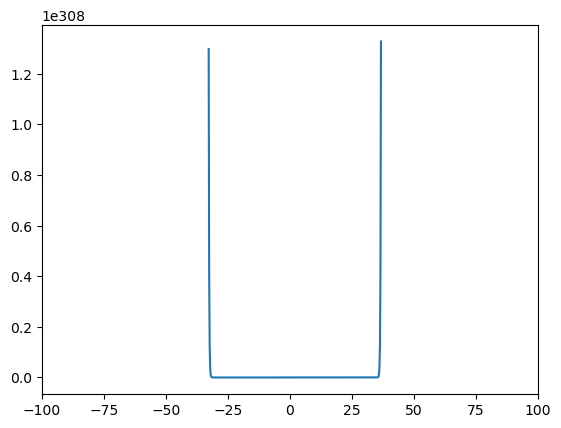

In [67]:
# 参数设置
t1 =1
t2 = 2
y1 = 2
y2 = 2
N = 100
E_set = np.linspace(-100, 100, 1000) 
F_E = np.array([abs(H_determinant(N, t1, t2, y1, y2, E)) for E in E_set])

plt.plot(E_set, F_E)
plt.xlim(E_set.min(),E_set.max())
plt.ylim(0,F_E.max())
plt.xlabel('E')
plt.ylabel('|det(H-EI)|')
plt.title('0')
plt.show()

In [141]:
import numpy as np
import matplotlib.pyplot as plt
import os
def draw_1(t1,t2,y1,y2,N,E_set): 
    F_E = np.array([abs(H_determinant(N, t1, t2, y1, y2, E)) for E in E_set])
    
    # 创建保存目录（如果不存在）
    save_dir = r"C:\Users\taoji\Desktop\结果\行列式的解"
    os.makedirs(save_dir, exist_ok=True)
    
    # 根据参数生成文件名
    filename = f"det_t1_{t1}_t2_{t2}_y1_{y1}_y2_{y2}_N_{N}_E_{E_set.min():.7f}to{E_set.max():.7f},{len(E_set)}.png"
    save_path = os.path.join(save_dir, filename)
    
    # 绘制图形
    plt.figure(figsize=(10, 6))
    plt.plot(E_set, F_E)
    plt.xlim(E_set.min(), E_set.max())
    plt.ylim(0, F_E.max())
    plt.xlabel('E')
    plt.ylabel('|det(H-EI)|')
    plt.title(f'Determinant vs Energy (t1={t1}, t2={t2}, y1={y1}, y2={y2}, N={N})')
    
    # 保存图像
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"图像已保存至: {save_path}")
    
    # 显示图形
    plt.show()

图像已保存至: C:\Users\taoji\Desktop\结果\行列式的解\det_t1_1_t2_2_y1_2_y2_2_N_100_E_-0.2300to4.2300.png


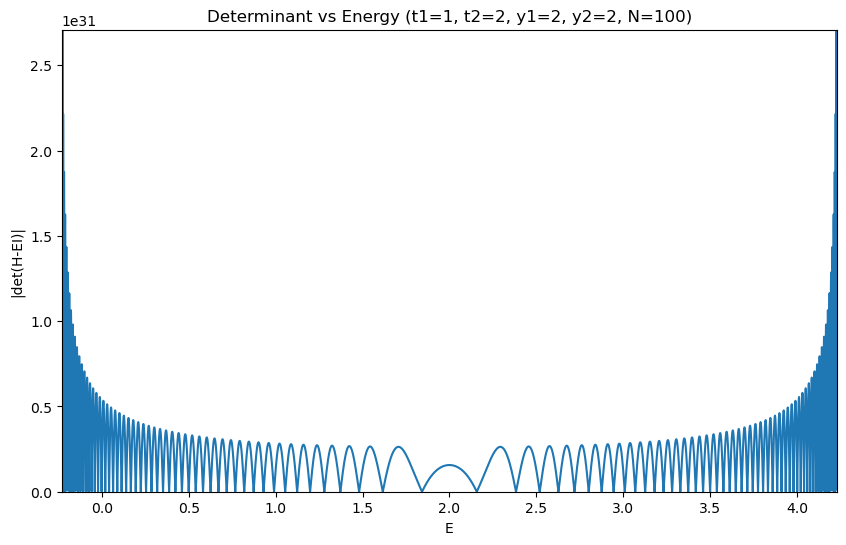

In [112]:
# 参数设置
t1 =1
t2 = 2
y1 = 2
y2 = 2
N = 100
E_set = np.linspace(-0.23, 4.23, 100000)
draw_1(t1,t2,y1,y2,N,E_set)

In [123]:
print(np.log(abs(H_determinant(N, t1, t2, y1, y2, 4.23))),abs(H_determinant(N, t1, t2, y1, y2, 4.23)))
print(np.log(abs(H_determinant(N, t1, t2, y1, y2, 4.24))),abs(H_determinant(N, t1, t2, y1, y2, 4.24)))

72.30424233060599 2.5196108066503995e+31
81.49522640668388 2.471309450067861e+35


In [133]:
import numpy as np
import matplotlib.pyplot as plt
import os
def draw_2(t1,t2,y1,y2,N,E_set): 
    F_E = np.array([abs(H_determinant(N, t1, t2, y1, y2, E)) for E in E_set])
    y=np.log(F_E)
    # 创建保存目录（如果不存在）
    save_dir = r"C:\Users\taoji\Desktop\结果\行列式的解"
    os.makedirs(save_dir, exist_ok=True)
    
    # 根据参数生成文件名
    filename = f"0_log_det_t1_{t1}_t2_{t2}_y1_{y1}_y2_{y2}_N_{N}_E_{E_set.min():.7f}to{E_set.max():.7f},{len(E_set)}.png"
    save_path = os.path.join(save_dir, filename)
    
    plt.figure(figsize=(10, 6))
    plt.plot(E_set, y)
    plt.xlim(E_set.min(), E_set.max())
    plt.ylim(0, y.max()*1.1)
    plt.xlabel('E')
    plt.ylabel('log(|det(H-EI)|)')
    plt.title(f'Determinant vs Energy (t1={t1}, t2={t2}, y1={y1}, y2={y2}, N={N})')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"图像已保存至: {save_path}")
    
    # 显示图形
    plt.show()

图像已保存至: C:\Users\taoji\Desktop\结果\行列式的解\0_log_det_t1_1_t2_2_y1_2_y2_2_N_100_E_-0.2300to4.2300,100000.png


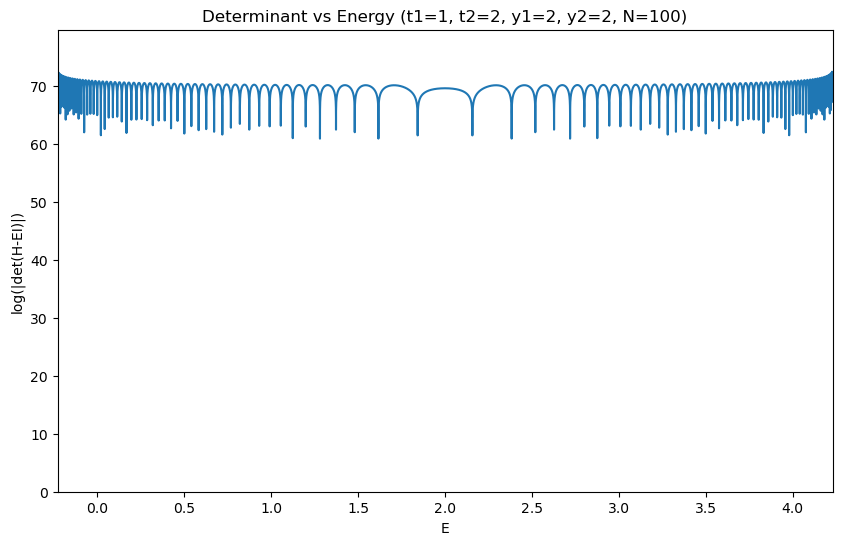

In [119]:
t1 =1
t2 = 2
y1 = 2
y2 = 2
N = 100
E_set = np.linspace(-0.23, 4.23, 100000)
draw_2(t1,t2,y1,y2,N,E_set)

图像已保存至: C:\Users\taoji\Desktop\结果\行列式的解\det_t1_1_t2_2_y1_2_y2_2_N_100_E_-0.2390000to-0.2350000,1000.png


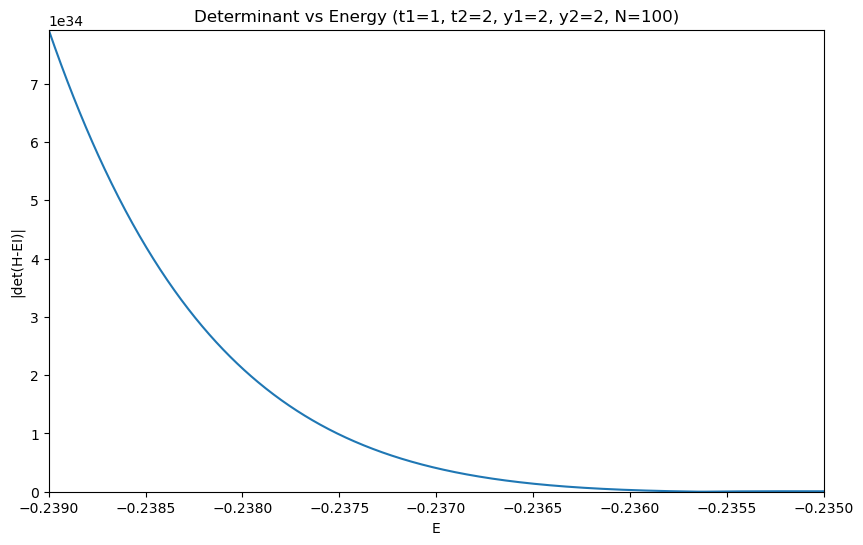

In [138]:
# 参数设置
t1 =1
t2 = 2
y1 = 2
y2 = 2
N = 100
E_set = np.linspace(-0.2390, -0.2350, 1000)
draw_1(t1,t2,y1,y2,N,E_set)

图像已保存至: C:\Users\taoji\Desktop\结果\行列式的解\0_log_det_t1_1_t2_2_y1_2_y2_2_N_100_E_-0.2356350to-0.2356250,1000.png


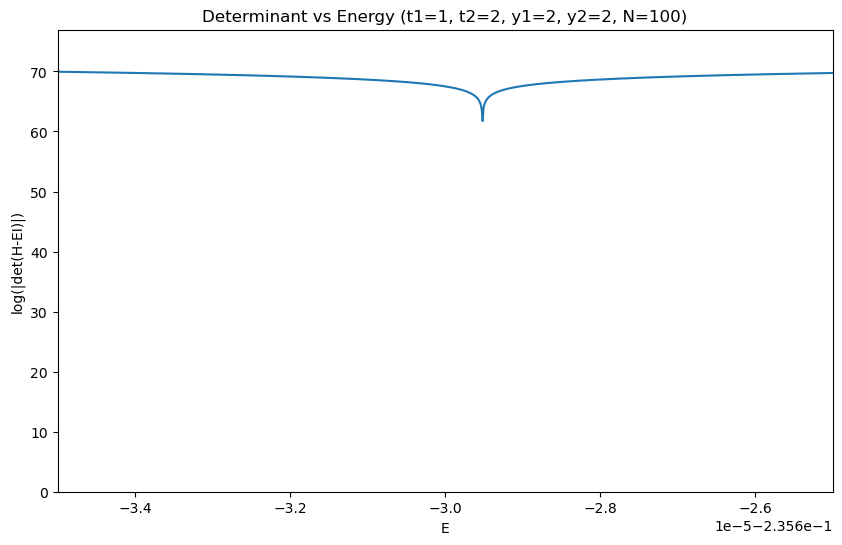

In [137]:
t1 =1
t2 = 2
y1 = 2
y2 = 2
N = 100
E_set = np.linspace(-0.235635, -0.235625, 1000)
draw_2(t1,t2,y1,y2,N,E_set)

In [158]:
import numpy as np             #C:\Users\taoji\Desktop\结果\行列式的解（中间）
import matplotlib.pyplot as plt
import os
def draw_3(t1,t2,y1,y2,N,E_set): 
    F_E = np.array([abs(H_determinant(N, t1, t2, y1, y2, E)) for E in E_set])
    
    # 创建保存目录（如果不存在）
    save_dir = r"C:\Users\taoji\Desktop\结果\行列式的解（中间）"
    os.makedirs(save_dir, exist_ok=True)
    
    # 根据参数生成文件名
    filename = f"det_t1_{t1}_t2_{t2}_y1_{y1}_y2_{y2}_N_{N}_E_{E_set.min():.16f}to{E_set.max():.16f},{len(E_set)}.png"
    save_path = os.path.join(save_dir, filename)
    
    # 绘制图形
    plt.figure(figsize=(10, 6))
    plt.plot(E_set, F_E)
    plt.xlim(E_set.min(), E_set.max())
    plt.ylim(0, F_E.max())
    plt.xlabel('E')
    plt.ylabel('|det(H-EI)|')
    plt.title(f'Determinant vs Energy (t1={t1}, t2={t2}, y1={y1}, y2={y2}, N={N})')
    
    # 保存图像
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"图像已保存至: {save_path}")
    
    # 显示图形
#    plt.show()

In [159]:
import numpy as np                   #C:\Users\taoji\Desktop\结果\行列式的解（中间）
import matplotlib.pyplot as plt
import os
def draw_4(t1,t2,y1,y2,N,E_set): 
    F_E = np.array([abs(H_determinant(N, t1, t2, y1, y2, E)) for E in E_set])
    y=np.log(F_E)
    # 创建保存目录（如果不存在）
    save_dir = r"C:\Users\taoji\Desktop\结果\行列式的解（中间）"
    os.makedirs(save_dir, exist_ok=True)
    
    # 根据参数生成文件名
    filename = f"0_log_det_t1_{t1}_t2_{t2}_y1_{y1}_y2_{y2}_N_{N}_E_{E_set.min():.16f}to{E_set.max():.16f},{len(E_set)}.png"
    save_path = os.path.join(save_dir, filename)
    
    plt.figure(figsize=(10, 6))
    plt.plot(E_set, y)
    plt.xlim(E_set.min(), E_set.max())
    plt.ylim(0, y.max()*1.1)
    plt.xlabel('E')
    plt.ylabel('log(|det(H-EI)|)')
    plt.title(f'Determinant vs Energy (t1={t1}, t2={t2}, y1={y1}, y2={y2}, N={N})')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"图像已保存至: {save_path}")


图像已保存至: C:\Users\taoji\Desktop\结果\行列式的解（中间）\det_t1_1_t2_2_y1_2_y2_2_N_100_E_1.6166317013600000to1.6166317013750000,10000.png
图像已保存至: C:\Users\taoji\Desktop\结果\行列式的解（中间）\0_log_det_t1_1_t2_2_y1_2_y2_2_N_100_E_1.6166317013600000to1.6166317013750000,10000.png


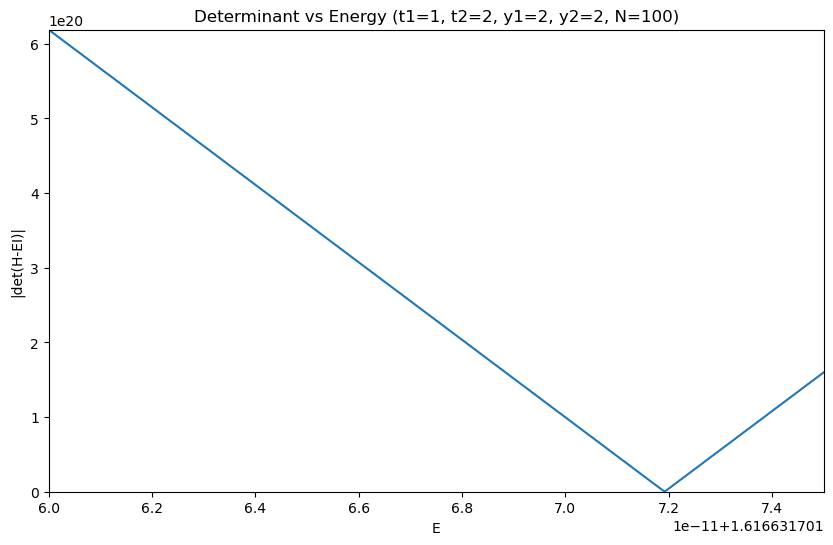

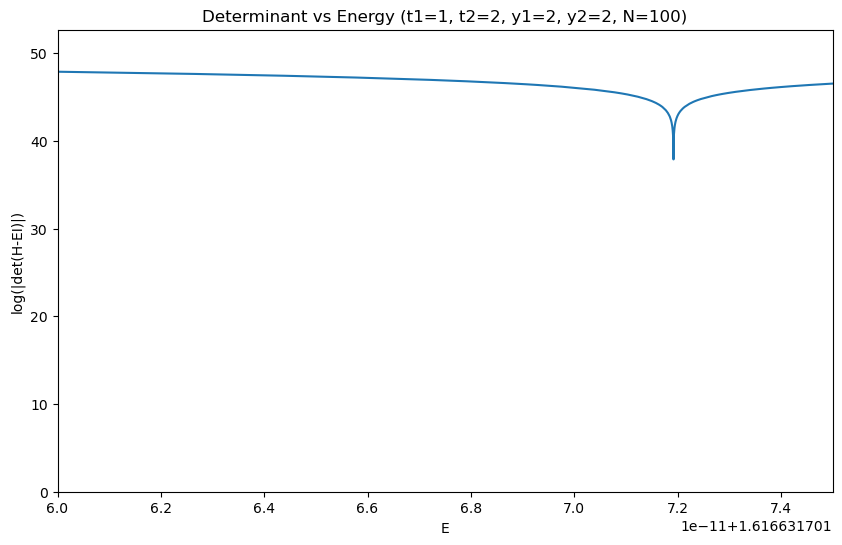

In [162]:
# 参数设置
t1 =1
t2 = 2
y1 = 2
y2 = 2
N = 100
E_set = np.linspace(1.616631701360, 1.616631701375, 10000)
draw_3(t1,t2,y1,y2,N,E_set)
draw_4(t1,t2,y1,y2,N,E_set)